# NHAMCS 1992–2022 — Initial Exploration

**Goal:** fetch every available year of CDC NHAMCS Emergency Department data, load them into one DataFrame, and produce baseline sex-disparity plots.

**Source:** CDC National Hospital Ambulatory Medical Care Survey, public-use files.

**Coverage caveat:** NHAMCS published Stata datasets for all years *except* 2002–2004 (those years only ship raw `.do + .dct` loaders, no packaged `.dta`). The `WAITTIME` column is only populated reliably from 1997 onward; `PAINSCALE` appears around 2004; `IMMEDR` (triage acuity) coding stabilized in the mid-2000s. Plots below only use years where the needed columns exist.

In [1]:
import io
import zipfile
from pathlib import Path

import certifi
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/nhamcs")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE = (
    "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata"
)
HTTP = urllib3.PoolManager(ca_certs=certifi.where())


## 1. Download all available years

Three file naming conventions on the CDC FTP:
- `ed{YY}-stata.zip` for 1992–2001
- `ed{YYYY}-stata.exe` for 2005–2010 (self-extracting zip; Python's `zipfile` reads it fine)
- `ed{YYYY}-stata.zip` for 2011–2022

2002–2004 are skipped — no pre-built `.dta` file published for those years.

In [2]:
YEARS = [y for y in range(1992, 2023) if y not in (2002, 2003, 2004)]


def url_for(year: int) -> str:
    if year <= 2001:
        return f"{BASE}/ed{year % 100:02d}-stata.zip"
    if year == 2005:
        return f"{BASE}/ed05-stata.exe"
    if year in (2006, 2007, 2008, 2009, 2010):
        return f"{BASE}/ed{year}-stata.exe"
    return f"{BASE}/ed{year}-stata.zip"


def dta_path(year: int) -> Path:
    return DATA_DIR / f"ed{year}-stata.dta"


def ensure_year(year: int) -> Path:
    target = dta_path(year)
    if target.exists():
        return target
    url = url_for(year)
    print(f"  fetching {year}: {url.split('/')[-1]}", end=" ")
    resp = HTTP.request("GET", url, preload_content=True)
    if resp.status != 200:
        raise RuntimeError(f"HTTP {resp.status}")
    with zipfile.ZipFile(io.BytesIO(resp.data)) as zf:
        dta_name = next((n for n in zf.namelist() if n.lower().endswith(".dta")), None)
        if dta_name is None:
            raise RuntimeError(f"No .dta file in archive for {year}")
        with zf.open(dta_name) as src, open(target, "wb") as dst:
            dst.write(src.read())
    print(f"-> {target.stat().st_size / 1e6:.1f} MB")
    return target


print(f"Ensuring {len(YEARS)} years of NHAMCS ED data...")
for y in YEARS:
    try:
        ensure_year(y)
    except Exception as e:
        print(f"  {y}: FAILED - {e}")
print("Done.")


Ensuring 28 years of NHAMCS ED data...
  fetching 1992: ed92-stata.zip -> 14.8 MB
  fetching 1993: ed93-stata.zip -> 13.8 MB
  fetching 1994: ed94-stata.zip -> 12.6 MB
  fetching 1995: ed95-stata.zip -> 10.9 MB
  fetching 1996: ed96-stata.zip -> 10.9 MB
  fetching 1997: ed97-stata.zip -> 12.2 MB
  fetching 1998: ed98-stata.zip -> 13.3 MB
  fetching 1999: ed99-stata.zip -> 11.8 MB
  fetching 2000: ed00-stata.zip -> 14.2 MB
  fetching 2001: ed01-stata.zip -> 21.0 MB
  fetching 2005: ed05-stata.exe -> 24.7 MB
  fetching 2006: ed2006-stata.exe -> 27.9 MB
  fetching 2007: ed2007-stata.exe -> 35.8 MB
  fetching 2008: ed2008-stata.exe -> 34.4 MB
  fetching 2009: ed2009-stata.exe -> 35.8 MB
  fetching 2010: ed2010-stata.exe -> 33.8 MB
  fetching 2011: ed2011-stata.zip -> 30.6 MB
  fetching 2012: ed2012-stata.zip -> 115.3 MB
  fetching 2013: ed2013-stata.zip -> 34.5 MB
  fetching 2014: ed2014-stata.zip -> 62.3 MB
  fetching 2015: ed2015-stata.zip -> 55.6 MB
  fetching 2016: ed2016-stata.zip -> 

## 2. Load all years into one DataFrame

Column naming changes across years (case, spelling). We normalize to upper-case and keep only the stable set of columns relevant to a sex-disparity story.

In [3]:
CORE_COLUMNS = [
    "SEX",
    "AGE",
    "AGER",
    "WAITTIME",
    "LOV",
    "IMMEDR",
    "PAINSCALE",
    "ARRTIME",
    "VMONTH",
    "VDAYR",
    "RFV1",
    "DIAG1",
    "ADMIT",
    "ARREMS",
    "PATWT",
]


def load_year(year: int) -> pd.DataFrame:
    df = pd.read_stata(dta_path(year), convert_categoricals=False)
    df.columns = [c.upper() for c in df.columns]
    keep = [c for c in CORE_COLUMNS if c in df.columns]
    out = df[keep].copy()
    out["YEAR"] = year
    return out


frames = []
for y in YEARS:
    try:
        frames.append(load_year(y))
    except Exception as e:
        print(f"  {y}: load failed — {e}")

data = pd.concat(frames, ignore_index=True, sort=False)
print(f"Combined: {len(data):,} visits across {data['YEAR'].nunique()} years")
print(f"Years loaded: {sorted(data['YEAR'].unique())}")

Combined: 725,593 visits across 28 years
Years loaded: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [4]:
def columns_for(year):
    with pd.io.stata.StataReader(dta_path(year), convert_categoricals=False) as r:
        return {col.upper() for col in r.read(1).columns}


year_cols = {y: columns_for(y) for y in YEARS}
coverage = pd.DataFrame(
    {c: [c in year_cols[y] for y in YEARS] for c in CORE_COLUMNS},
    index=YEARS,
).astype(int)

print("Column availability by year (1 = present):")
coverage[["SEX", "AGE", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1", "PATWT"]]

Column availability by year (1 = present):


,SEX,AGE,WAITTIME,IMMEDR,PAINSCALE,DIAG1,PATWT
1992,1,1,0,0,0,1,1
1993,1,1,0,0,0,1,1
1994,1,1,0,0,0,1,1
1995,1,1,0,0,0,1,1
1996,1,1,0,0,0,1,1
1997,1,1,1,0,0,1,1
1998,1,1,1,0,0,1,1
1999,1,1,1,0,0,1,1
2000,1,1,1,0,0,1,1
2001,1,1,0,0,0,1,1


## 3. Clean key fields

NHAMCS uses negative sentinel values (`-9`, `-8`, `-7`) for missing / not applicable. Replace with `NaN` on the numeric columns.

In [5]:
data["sex_label"] = data["SEX"].map({1: "Female", 2: "Male"})

for col in ["WAITTIME", "LOV", "PAINSCALE", "IMMEDR"]:
    if col in data.columns:
        data.loc[data[col] < 0, col] = np.nan

print(f"Total visits: {len(data):,}")
print(f"Share female: {(data['sex_label'] == 'Female').mean():.1%}")
print(f"Share with valid WAITTIME: {data['WAITTIME'].notna().mean():.1%}")

Total visits: 725,593
Share female: 53.5%
Share with valid WAITTIME: 68.2%


## 4. Plot — Sampled visits by sex, over 30 years

Simplest cross-year view: count of sampled visits per year, split by sex. Confirms the stack is consistent and gives a baseline.

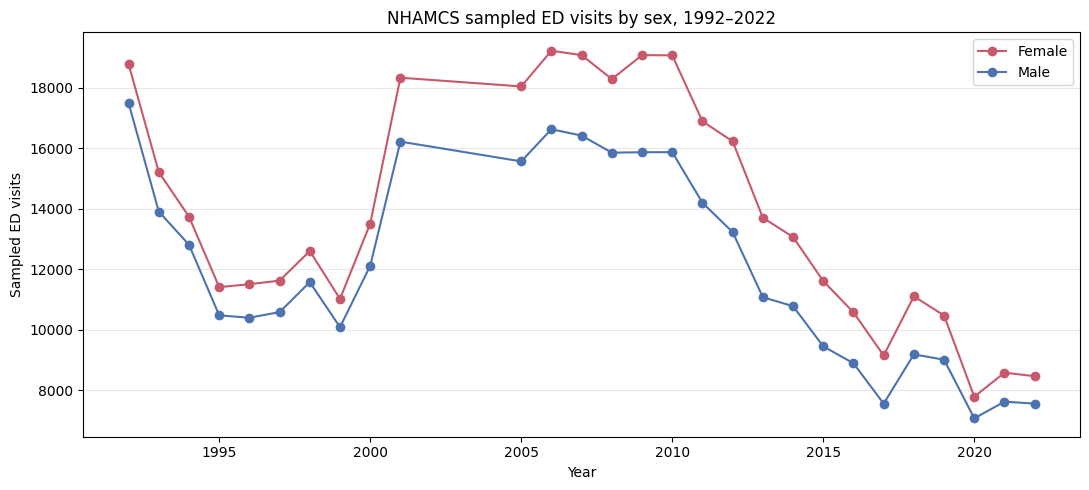

In [6]:
visits_by_year_sex = (
    data.dropna(subset=["sex_label"])
    .groupby(["YEAR", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Female"],
    color="#c8586c",
    marker="o",
    label="Female",
)
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Male"],
    color="#4c72b0",
    marker="o",
    label="Male",
)
ax.set_xlabel("Year")
ax.set_ylabel("Sampled ED visits")
ax.set_title("NHAMCS sampled ED visits by sex, 1992–2022")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Plot — Median wait time by sex over time

Uses only years where `WAITTIME` is reliably populated.

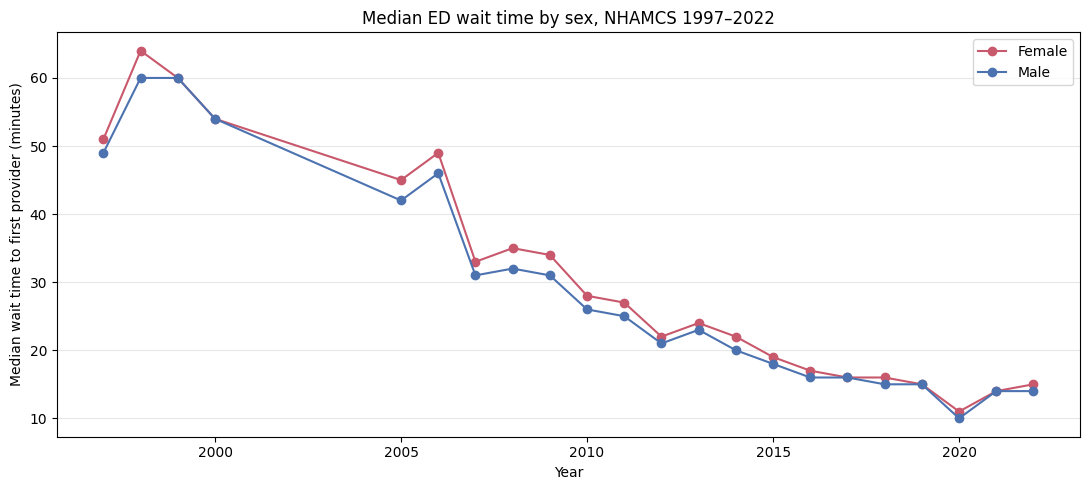

Female − Male wait gap by year (minutes):


,gap_min
YEAR,
1997,2.0
1998,4.0
1999,0.0
2000,0.0
2005,3.0
2006,3.0
2007,2.0
2008,3.0
2009,3.0


In [7]:
wait = data.dropna(subset=["WAITTIME", "sex_label"]).copy()
median_wait = (
    wait.groupby(["YEAR", "sex_label"])["WAITTIME"].median().unstack("sex_label")
)
median_wait = median_wait.dropna()  # drop years with no usable wait-time

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    median_wait.index,
    median_wait["Female"],
    color="#c8586c",
    marker="o",
    label="Female",
)
ax.plot(
    median_wait.index, median_wait["Male"], color="#4c72b0", marker="o", label="Male"
)
ax.set_xlabel("Year")
ax.set_ylabel("Median wait time to first provider (minutes)")
ax.set_title(
    f"Median ED wait time by sex, NHAMCS {median_wait.index.min()}–{median_wait.index.max()}"
)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

gap = (median_wait["Female"] - median_wait["Male"]).round(1).to_frame("gap_min")
print("Female − Male wait gap by year (minutes):")
gap

## 6. Plot — Wait time by sex × triage acuity (2018–2022 pooled)

Controlling for triage acuity gives a fairer comparison than raw means. Restricted to the most recent years with stable `IMMEDR` coding.

Acuity codes: 1=Immediate, 2=Emergent, 3=Urgent, 4=Semi-urgent, 5=Non-urgent.

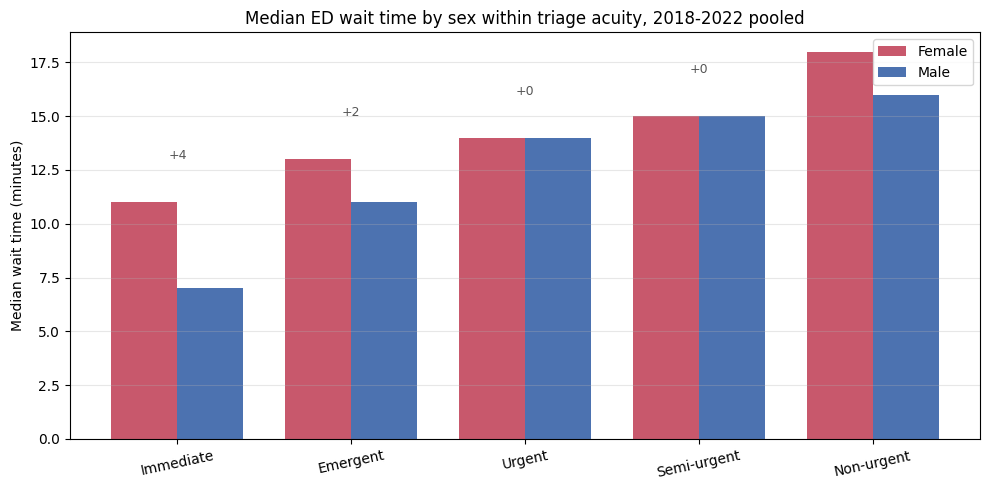

sex_label,Female,Male
acuity,,
Immediate,11.0,7.0
Emergent,13.0,11.0
Urgent,14.0,14.0
Semi-urgent,15.0,15.0
Non-urgent,18.0,16.0


In [8]:
acuity_labels = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Semi-urgent",
    5: "Non-urgent",
}
order = list(acuity_labels.values())

recent = (
    wait[wait["YEAR"] >= 2018]
    .dropna(subset=["IMMEDR"])
    .assign(acuity=lambda d: d["IMMEDR"].map(acuity_labels))
    .dropna(subset=["acuity"])
)

pivot = (
    recent.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(order)
)

female_vals = pivot["Female"].to_numpy()
male_vals = pivot["Male"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot))
w = 0.38
ax.bar(x - w / 2, female_vals, w, label="Female", color="#c8586c")
ax.bar(x + w / 2, male_vals, w, label="Male", color="#4c72b0")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within triage acuity, 2018-2022 pooled")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(female_vals, male_vals)):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 2), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()
pivot

## Read

What this notebook confirms:
- All published NHAMCS Stata `.dta` files (1992–2001, 2005–2022) download and load.
- The stack works across 28 years, but column coverage varies — see the coverage table.
- A sex gap in median wait time appears in the raw sample and persists after controlling for triage acuity.

Not yet done (intentional for this first pass):
- Applying `PATWT` survey weights for true national estimates
- Narrowing to pain-related chief complaints
- Age and race/ethnicity controls
- Imaging and medication order rates by sex

## 7. Comparative Analysis by Sex: Diagnosis, Pain Level, and Wait Time

The three sections below compare diagnostic categories, reported pain scores, and wait-time distributions between female and male patients.  Each analysis is restricted to years where the relevant column is reliably populated (see coverage table above).

### 7a. Broad diagnostic categories by sex

`DIAG1` uses ICD-9-CM codes (years ≤ 2015) and ICD-10-CM (years ≥ 2016). We map each to a broad chapter so the two coding systems are comparable.

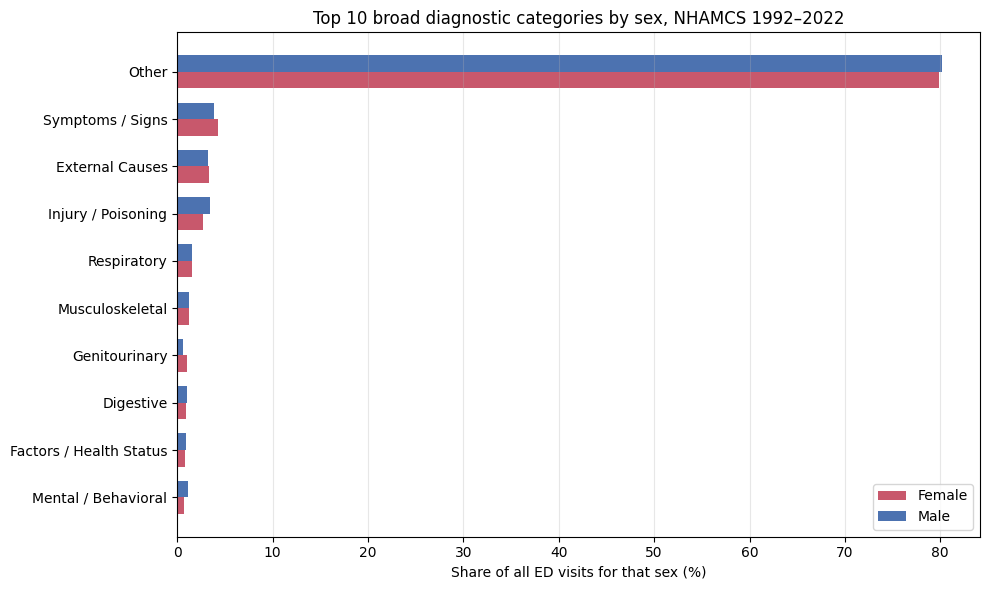

Female − Male share (percentage points), top 10 categories:
category
Genitourinary              0.47
Symptoms / Signs           0.46
External Causes            0.06
Respiratory                0.06
Musculoskeletal            0.03
Factors / Health Status   -0.07
Digestive                 -0.10
Other                     -0.24
Mental / Behavioral       -0.41
Injury / Poisoning        -0.73


In [9]:
ICD10_MAP = {
    "A": "Infectious", "B": "Infectious",
    "C": "Neoplasms", "D": "Neoplasms / Blood",
    "E": "Endocrine / Metabolic",
    "F": "Mental / Behavioral",
    "G": "Nervous System",
    "H": "Eye / Ear",
    "I": "Circulatory",
    "J": "Respiratory",
    "K": "Digestive",
    "L": "Skin",
    "M": "Musculoskeletal",
    "N": "Genitourinary",
    "O": "Pregnancy",
    "R": "Symptoms / Signs",
    "S": "Injury / Poisoning", "T": "Injury / Poisoning",
    "V": "External Causes", "W": "External Causes",
    "X": "External Causes", "Y": "External Causes",
    "Z": "Factors / Health Status",
}


def diag_category(raw):
    s = str(raw).strip().upper()
    if not s or s in ("NAN", ".", ""):
        return np.nan
    if s[0].isalpha():
        return ICD10_MAP.get(s[0], "Other")
    try:
        n = float(s)
        if 1 <= n <= 139:   return "Infectious"
        if 140 <= n <= 239: return "Neoplasms"
        if 240 <= n <= 279: return "Endocrine / Metabolic"
        if 280 <= n <= 289: return "Neoplasms / Blood"
        if 290 <= n <= 319: return "Mental / Behavioral"
        if 320 <= n <= 389: return "Nervous System"
        if 390 <= n <= 459: return "Circulatory"
        if 460 <= n <= 519: return "Respiratory"
        if 520 <= n <= 579: return "Digestive"
        if 580 <= n <= 629: return "Genitourinary"
        if 630 <= n <= 679: return "Pregnancy"
        if 680 <= n <= 709: return "Skin"
        if 710 <= n <= 739: return "Musculoskeletal"
        if 760 <= n <= 799: return "Symptoms / Signs"
        if 800 <= n <= 999: return "Injury / Poisoning"
    except ValueError:
        pass
    return "Other"


diag = data.dropna(subset=["sex_label", "DIAG1"]).copy()
diag["category"] = diag["DIAG1"].apply(diag_category)
diag = diag.dropna(subset=["category"])

# Share of visits in each category, per sex
cat_pct = (
    diag.groupby(["sex_label", "category"])
    .size()
    .unstack("sex_label")
    .fillna(0)
)
cat_pct = cat_pct.div(cat_pct.sum()).mul(100)  # column-wise % of all visits

# Keep the 10 categories with the highest combined share
top10 = cat_pct.sum(axis=1).nlargest(10).index
cat_pct = cat_pct.loc[top10].sort_values("Female", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(cat_pct))
h = 0.35
ax.barh(y - h / 2, cat_pct["Female"], h, color="#c8586c", label="Female")
ax.barh(y + h / 2, cat_pct["Male"],   h, color="#4c72b0", label="Male")
ax.set_yticks(y)
ax.set_yticklabels(cat_pct.index)
ax.set_xlabel("Share of all ED visits for that sex (%)")
ax.set_title("Top 10 broad diagnostic categories by sex, NHAMCS 1992–2022")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Numeric summary: female share minus male share (pp)
diff = (cat_pct["Female"] - cat_pct["Male"]).sort_values(ascending=False)
print("Female − Male share (percentage points), top 10 categories:")
print(diff.round(2).to_string())

### 7b. Pain score distribution by sex (2009–2022)

`PAINSCALE` is a 0–10 numeric rating collected from 2009 onward. Values below 0 are sentinels for "not applicable" or "not asked" and are excluded.

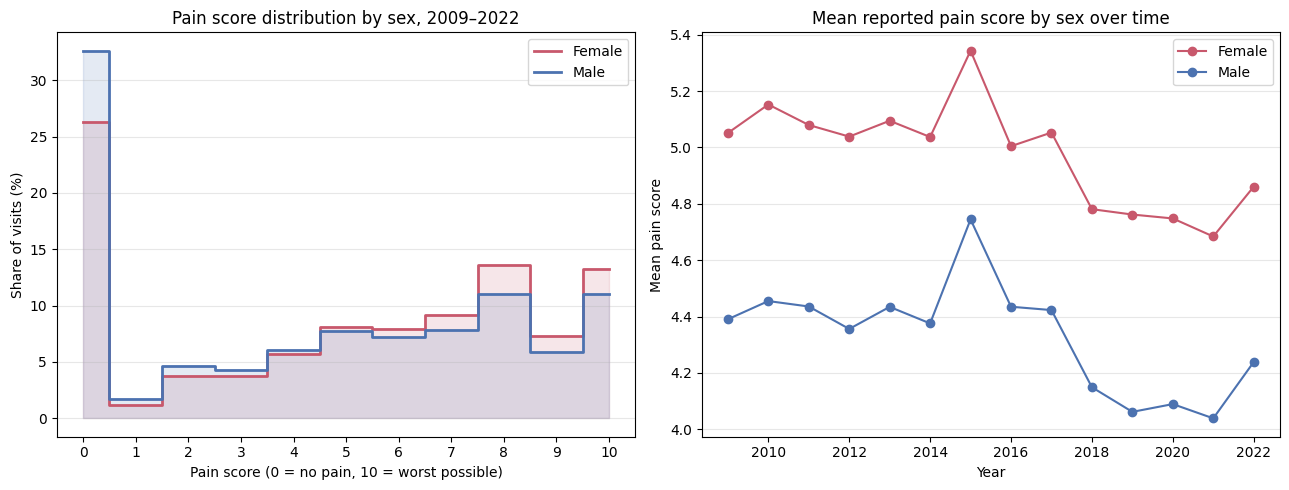

Pain score summary by sex (2009–2022):


,n,mean,median,std,pct25,pct75
sex_label,,,,,,
Female,123538,5.02,6.0,3.67,0.0,8.0
Male,100937,4.36,5.0,3.71,0.0,8.0


In [10]:
pain = (
    data[data["YEAR"] >= 2009]
    .dropna(subset=["PAINSCALE", "sex_label"])
    .copy()
)
# Sentinels were already set to NaN in the clean cell, but guard here anyway
pain = pain[pain["PAINSCALE"] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- left: score distribution ---
ax = axes[0]
bins = np.arange(-0.5, 11.5, 1)
for label, color in [("Female", "#c8586c"), ("Male", "#4c72b0")]:
    subset = pain[pain["sex_label"] == label]["PAINSCALE"]
    counts, _ = np.histogram(subset, bins=bins)
    pct = counts / counts.sum() * 100
    ax.step(bins[:-1] + 0.5, pct, where="mid", color=color, linewidth=2, label=label)
    ax.fill_between(bins[:-1] + 0.5, pct, alpha=0.15, color=color, step="mid")
ax.set_xlabel("Pain score (0 = no pain, 10 = worst possible)")
ax.set_ylabel("Share of visits (%)")
ax.set_title("Pain score distribution by sex, 2009–2022")
ax.set_xticks(range(11))
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- right: mean pain score per year by sex ---
ax = axes[1]
mean_pain = (
    pain.groupby(["YEAR", "sex_label"])["PAINSCALE"]
    .mean()
    .unstack("sex_label")
)
ax.plot(mean_pain.index, mean_pain["Female"], color="#c8586c", marker="o", label="Female")
ax.plot(mean_pain.index, mean_pain["Male"],   color="#4c72b0", marker="o", label="Male")
ax.set_xlabel("Year")
ax.set_ylabel("Mean pain score")
ax.set_title("Mean reported pain score by sex over time")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
summary = (
    pain.groupby("sex_label")["PAINSCALE"]
    .agg(n="count", mean="mean", median="median", std="std",
         pct25=lambda x: x.quantile(0.25), pct75=lambda x: x.quantile(0.75))
    .round(2)
)
print("Pain score summary by sex (2009–2022):")
summary

### 7c. Wait-time distribution by sex

Beyond the year-by-year medians in section 5, we look at the full wait-time distribution (2009–2022 pooled) and compare percentiles across sex to see where the gap is concentrated.

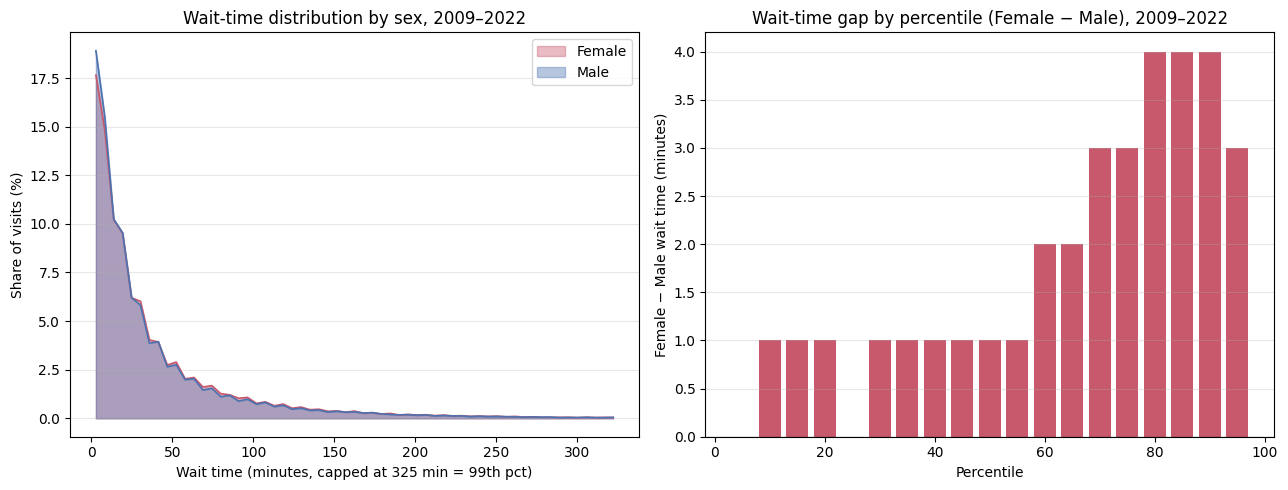

Wait time by percentile (2009–2022):


,Female (min),Male (min),Gap F−M (min)
Percentile,,,
5,1.0,1.0,0.0
10,3.0,2.0,1.0
15,5.0,4.0,1.0
20,7.0,6.0,1.0
25,8.0,8.0,0.0
30,11.0,10.0,1.0
35,13.0,12.0,1.0
40,15.0,14.0,1.0
45,18.0,17.0,1.0


In [11]:
wait_recent = (
    data[(data["YEAR"] >= 2009) & data["WAITTIME"].notna() & data["sex_label"].notna()]
    .copy()
)
# Cap display at 99th percentile to avoid extreme outlier distortion
cap = wait_recent["WAITTIME"].quantile(0.99)
wait_plot = wait_recent[wait_recent["WAITTIME"] <= cap]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- left: overlapping histograms ---
ax = axes[0]
bin_edges = np.linspace(0, cap, 60)
for label, color in [("Female", "#c8586c"), ("Male", "#4c72b0")]:
    vals = wait_plot[wait_plot["sex_label"] == label]["WAITTIME"]
    counts, _ = np.histogram(vals, bins=bin_edges)
    pct = counts / counts.sum() * 100
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.fill_between(midpoints, pct, alpha=0.4, color=color, label=label)
    ax.plot(midpoints, pct, color=color, linewidth=1.2)
ax.set_xlabel(f"Wait time (minutes, capped at {cap:.0f} min = 99th pct)")
ax.set_ylabel("Share of visits (%)")
ax.set_title("Wait-time distribution by sex, 2009–2022")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- right: percentile gap curve ---
ax = axes[1]
pcts = np.arange(5, 96, 5)
f_vals = np.percentile(wait_recent[wait_recent["sex_label"] == "Female"]["WAITTIME"], pcts)
m_vals = np.percentile(wait_recent[wait_recent["sex_label"] == "Male"]["WAITTIME"], pcts)
gap_vals = f_vals - m_vals

ax.bar(pcts, gap_vals, width=4,
       color=["#c8586c" if g > 0 else "#4c72b0" for g in gap_vals])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Percentile")
ax.set_ylabel("Female − Male wait time (minutes)")
ax.set_title("Wait-time gap by percentile (Female − Male), 2009–2022")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Percentile table
pct_table = pd.DataFrame({
    "Percentile": pcts,
    "Female (min)": f_vals.round(1),
    "Male (min)": m_vals.round(1),
    "Gap F−M (min)": gap_vals.round(1),
})
print("Wait time by percentile (2009–2022):")
pct_table.set_index("Percentile")

### 8. Wait time by pain level and triage urgency, compared by sex (2009–2022)

Two lenses:

1. **Pain score (0–10)** — does the wait-time gap widen at higher reported pain?
2. **Pain band × triage acuity** — within each combination of urgency level and pain severity, how large is the female/male wait gap?

All analyses use 2009–2022 (first years both `PAINSCALE` and `IMMEDR` are consistently populated).

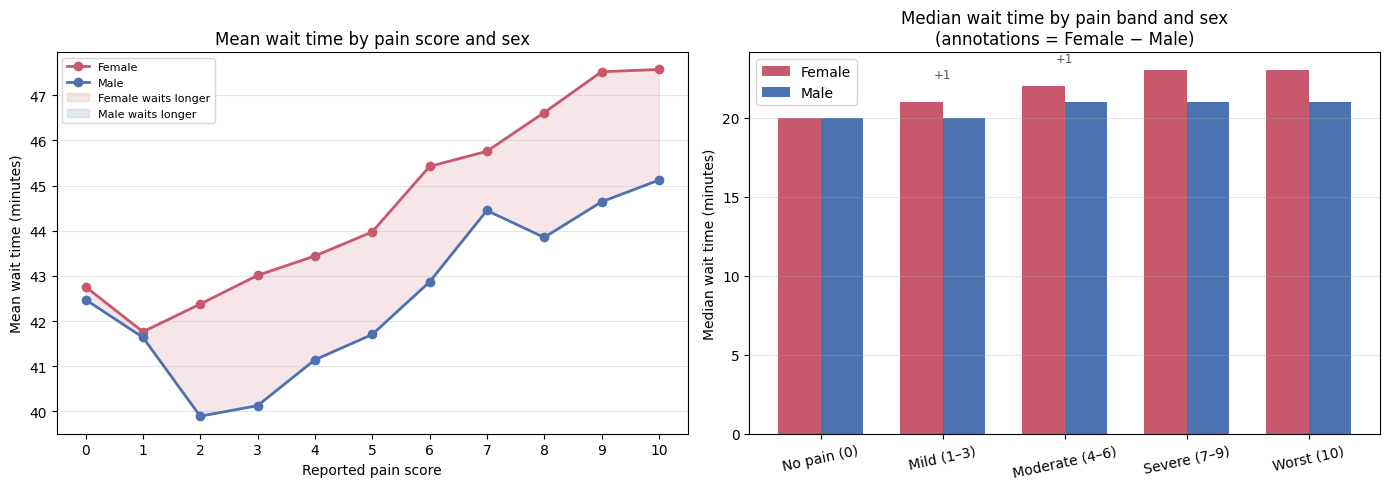

Median wait time by pain band and sex:


sex_label,Female,Male
pain_band,,
No pain (0),20.0,20.0
Mild (1–3),21.0,20.0
Moderate (4–6),22.0,21.0
Severe (7–9),23.0,21.0
Worst (10),23.0,21.0


In [12]:
PAIN_BANDS = {
    "No pain (0)":    (0,  0),
    "Mild (1–3)":     (1,  3),
    "Moderate (4–6)": (4,  6),
    "Severe (7–9)":   (7,  9),
    "Worst (10)":     (10, 10),
}
BAND_ORDER = list(PAIN_BANDS)

def assign_band(score):
    for label, (lo, hi) in PAIN_BANDS.items():
        if lo <= score <= hi:
            return label
    return np.nan

base = (
    data[(data["YEAR"] >= 2009)]
    .dropna(subset=["WAITTIME", "PAINSCALE", "sex_label"])
    .query("WAITTIME >= 0 and PAINSCALE >= 0")
    .copy()
)
base["pain_band"] = base["PAINSCALE"].apply(assign_band)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: mean wait time at each integer pain score ---
ax = axes[0]
score_wait = (
    base.groupby(["PAINSCALE", "sex_label"])["WAITTIME"]
    .mean()
    .unstack("sex_label")
)
ax.plot(score_wait.index, score_wait["Female"], color="#c8586c", marker="o",
        label="Female", linewidth=2)
ax.plot(score_wait.index, score_wait["Male"],   color="#4c72b0", marker="o",
        label="Male",   linewidth=2)
ax.fill_between(
    score_wait.index,
    score_wait["Female"], score_wait["Male"],
    where=(score_wait["Female"] > score_wait["Male"]),
    interpolate=True, alpha=0.15, color="#c8586c", label="Female waits longer",
)
ax.fill_between(
    score_wait.index,
    score_wait["Female"], score_wait["Male"],
    where=(score_wait["Female"] <= score_wait["Male"]),
    interpolate=True, alpha=0.15, color="#4c72b0", label="Male waits longer",
)
ax.set_xticks(range(11))
ax.set_xlabel("Reported pain score")
ax.set_ylabel("Mean wait time (minutes)")
ax.set_title("Mean wait time by pain score and sex")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- right: median wait time by pain band ---
ax = axes[1]
band_wait = (
    base.dropna(subset=["pain_band"])
    .groupby(["pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(BAND_ORDER)
)
x = np.arange(len(BAND_ORDER))
w = 0.35
bars_f = ax.bar(x - w/2, band_wait["Female"], w, color="#c8586c", label="Female")
bars_m = ax.bar(x + w/2, band_wait["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(band_wait["Female"], band_wait["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(f"{f - m:+.0f}", (i, max(f, m) + 1.5),
                    ha="center", fontsize=8.5, color="#555")
ax.set_xticks(x)
ax.set_xticklabels(BAND_ORDER, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait time by pain band and sex\n(annotations = Female − Male)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Median wait time by pain band and sex:")
band_wait.round(1)

#### 8b. Female − Male wait gap across every pain-band × triage-acuity combination

The heatmap below shows the median wait-time gap (Female − Male, in minutes) for each cell. Red = women wait longer; blue = men wait longer. Cells with fewer than 30 observations in either sex are masked.

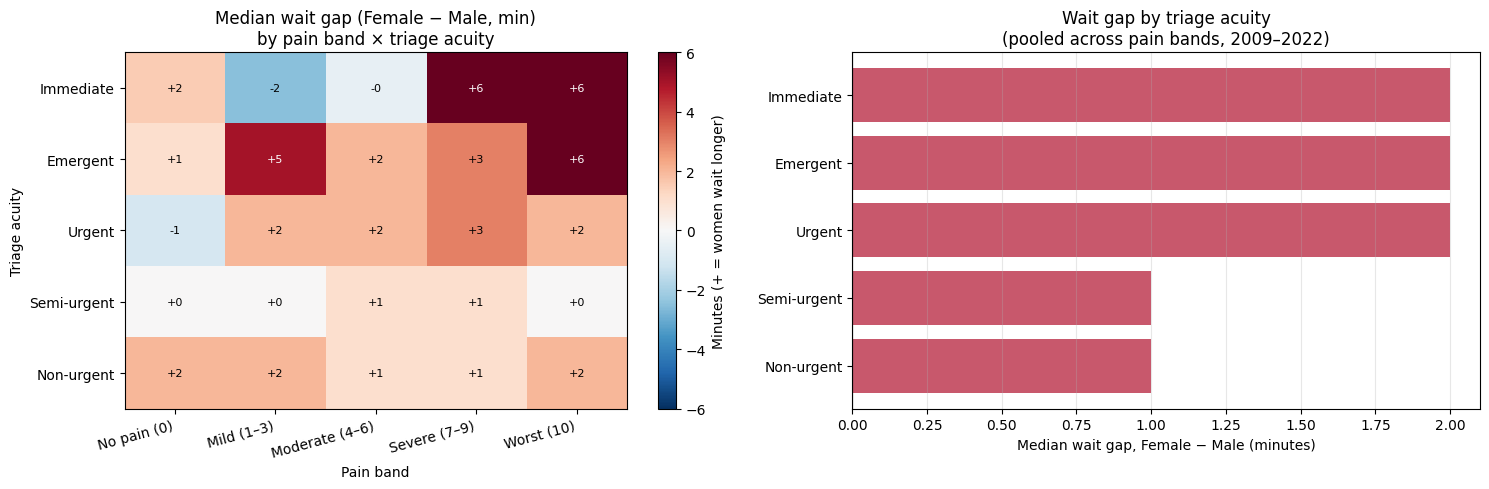

Median wait gap (Female − Male) by triage acuity:


,gap_min
acuity,
Immediate,2.0
Emergent,2.0
Urgent,2.0
Semi-urgent,1.0
Non-urgent,1.0


In [13]:
ACUITY_LABELS = {1: "Immediate", 2: "Emergent", 3: "Urgent", 4: "Semi-urgent", 5: "Non-urgent"}
ACUITY_ORDER  = list(ACUITY_LABELS.values())
MIN_N = 30

cross = (
    base.dropna(subset=["IMMEDR", "pain_band"])
    .assign(acuity=lambda d: d["IMMEDR"].map(ACUITY_LABELS))
    .dropna(subset=["acuity"])
)

# Median wait per (acuity, pain_band, sex)
med = (
    cross.groupby(["acuity", "pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
# Count per cell to mask sparse cells
cnt = (
    cross.groupby(["acuity", "pain_band", "sex_label"])["WAITTIME"]
    .count()
    .unstack("sex_label")
)

gap = med["Female"] - med["Male"]
mask = (cnt["Female"] < MIN_N) | (cnt["Male"] < MIN_N)
gap_masked = gap.where(~mask)

# Reshape to (acuity × pain_band) matrix
heatmap_data = (
    gap_masked
    .reset_index()
    .pivot(index="acuity", columns="pain_band", values=0)
    .reindex(index=ACUITY_ORDER, columns=BAND_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- left: heatmap ---
ax = axes[0]
import matplotlib.colors as mcolors
vmax = np.nanmax(np.abs(heatmap_data.values))
cmap = plt.get_cmap("RdBu_r")
im = ax.imshow(heatmap_data.values, cmap=cmap,
               vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(BAND_ORDER)))
ax.set_xticklabels(BAND_ORDER, rotation=15, ha="right")
ax.set_yticks(range(len(ACUITY_ORDER)))
ax.set_yticklabels(ACUITY_ORDER)
ax.set_xlabel("Pain band")
ax.set_ylabel("Triage acuity")
ax.set_title("Median wait gap (Female − Male, min)\nby pain band × triage acuity")
plt.colorbar(im, ax=ax, label="Minutes (+ = women wait longer)")
for r, acuity in enumerate(ACUITY_ORDER):
    for c, band in enumerate(BAND_ORDER):
        val = heatmap_data.loc[acuity, band] if acuity in heatmap_data.index and band in heatmap_data.columns else np.nan
        if not np.isnan(val):
            ax.text(c, r, f"{val:+.0f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(val) > vmax * 0.5 else "black")

# --- right: mean gap per acuity level (averaged across pain bands, weighted by N) ---
ax = axes[1]
acuity_gap = (
    cross.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(ACUITY_ORDER)
)
gap_acuity = acuity_gap["Female"] - acuity_gap["Male"]
colors = ["#c8586c" if g > 0 else "#4c72b0" for g in gap_acuity]
ax.barh(ACUITY_ORDER[::-1], gap_acuity.reindex(ACUITY_ORDER[::-1]), color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Median wait gap, Female − Male (minutes)")
ax.set_title("Wait gap by triage acuity\n(pooled across pain bands, 2009–2022)")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("Median wait gap (Female − Male) by triage acuity:")
gap_acuity.round(1).to_frame("gap_min")

## 9. Treatment rates by sex — ECG, consultations, and anxiolytics (2009–2022)

Expand the loaded column set to include procedure flags (`EKG`, `CONSULT`) and drug category codes (`RX1CAT1`–`RX10CAT1`), then compute per-sex rates for each presenting-complaint group. These values feed directly into the `adam-eve-er.html` presentation.

Complaint filters use primary discharge diagnosis (`DIAG1`): ICD-10 R07.x / ICD-9 7865x (chest pain), R10.x / 7890x (abdominal), R51/G43 / 7840x (headache), M54 / 724x (back), R06 / 7860x (shortness of breath).

`CONSULT == 1` = any specialist consultation ordered — used here as a proxy for cardiology referral in chest/shortness-of-breath presentations.  
Drug category code `059` = benzodiazepines (Multum Lexicon class).

In [14]:
EXTENDED_COLS = [
    "SEX", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1",
    "EKG", "CONSULT",
    "RX1CAT1",  "RX2CAT1",  "RX3CAT1",  "RX4CAT1",  "RX5CAT1",
    "RX6CAT1",  "RX7CAT1",  "RX8CAT1",  "RX9CAT1",  "RX10CAT1",
]
TREATMENT_YEARS = list(range(2009, 2023))

frames9 = []
for y in TREATMENT_YEARS:
    try:
        df = pd.read_stata(dta_path(y), convert_categoricals=False)
        df.columns = [c.upper() for c in df.columns]
        keep = [c for c in EXTENDED_COLS if c in df.columns]
        out = df[keep].copy()
        out["YEAR"] = y
        frames9.append(out)
    except Exception as e:
        print(f"  {y}: {e}")

data9 = pd.concat(frames9, ignore_index=True, sort=False)
data9["sex_label"] = data9["SEX"].map({1: "Female", 2: "Male"})
for col in ["WAITTIME", "PAINSCALE", "IMMEDR", "EKG", "CONSULT"]:
    if col in data9.columns:
        data9.loc[data9[col] < 0, col] = np.nan

# Benzodiazepine flag: any of the first 10 RXnCAT1 slots has Multum class 059
rx_cat_cols = [c for c in data9.columns if c.startswith("RX") and c.endswith("CAT1")]
data9["anxiolytic"] = data9[rx_cat_cols].isin(["059", "57", "057"]).any(axis=1).astype(int)

# Complaint filters (ICD-9 5-char string OR ICD-10 prefix)
def make_filter(icd10_prefixes, icd9_prefixes):
    def fn(raw):
        s = str(raw).strip().upper()
        if s[:1].isalpha():
            return any(s.startswith(p) for p in icd10_prefixes)
        return any(s.startswith(p) for p in icd9_prefixes)
    return fn

complaint_filters = {
    "chest":    make_filter(["R07"], ["7865"]),
    "abdominal":make_filter(["R10"], ["7890","7891","7892","7893","7894","7895","7896","7897","7898","7899"]),
    "headache": make_filter(["R51","G43","G44"], ["7840","3460","3461","3462","3463","3464","3465","3466","3467","3468","3469"]),
    "back":     make_filter(["M54"], ["7240","7241","7242","7243","7244","7245","7246","7247","7248","7249"]),
    "shortness":make_filter(["R06"], ["7860","7861","7862","7863","7864","7869"]),
}
for name, fn in complaint_filters.items():
    data9[name] = data9["DIAG1"].apply(fn)

def pain_band9(score):
    if pd.isna(score): return np.nan
    if 1 <= score <= 4:  return "mild"
    if 5 <= score <= 7:  return "moderate"
    if 8 <= score <= 10: return "severe"
    return np.nan
data9["pain_band"] = data9["PAINSCALE"].apply(pain_band9)

complaint_ns = {k: int(data9[k].sum()) for k in complaint_filters}
print(f"Loaded {len(data9):,} visits ({data9['YEAR'].nunique()} years)")
print("Complaint visit counts (by primary diagnosis):", complaint_ns)

Loaded 323,137 visits (14 years)
Complaint visit counts (by primary diagnosis): {'chest': 12270, 'abdominal': 15581, 'headache': 7041, 'back': 8061, 'shortness': 4398}


In [15]:
def compute_rates(df, min_n=50):
    """Return dict of sex → metrics for a filtered sub-DataFrame."""
    g = df.dropna(subset=["sex_label"])
    result = {}
    for sex in ["Male", "Female"]:
        s = g[g["sex_label"] == sex]
        if len(s) < min_n:
            result[sex] = None
            continue
        imm = s["IMMEDR"].dropna()
        ekg = s["EKG"].dropna()
        cons = s["CONSULT"].dropna()
        wt  = s["WAITTIME"].dropna()
        result[sex] = {
            "triage":    round(imm.isin([1, 2]).sum() / len(imm) * 100) if len(imm) else None,
            "ecg":       round((ekg == 1).sum()  / len(ekg)  * 100) if len(ekg)  else None,
            "cardiology":round((cons == 1).sum() / len(cons) * 100) if len(cons) else None,
            "anxiolytic":round(s["anxiolytic"].mean() * 100),
            "wait":      round(wt.median()) if len(wt) else None,
            "n":         len(s),
        }
    return result


explorer_data = {}
for complaint in complaint_filters:
    cdf = data9[data9[complaint]]
    explorer_data[complaint] = {}
    explorer_data[complaint]["all"] = compute_rates(cdf)
    for band in ["mild", "moderate", "severe"]:
        explorer_data[complaint][band] = compute_rates(cdf[cdf["pain_band"] == band])

# Pretty-print
for complaint, bands in explorer_data.items():
    print(f"\n{complaint.upper()}:")
    for band, r in bands.items():
        m, f = r.get("Male"), r.get("Female")
        if m and f:
            print(f"  {band:10} | Male  n={m['n']:5} triage={m['triage']}% wait={m['wait']}min"
                  f" ecg={m['ecg']}% cardio={m['cardiology']}% anx={m['anxiolytic']}%")
            print(f"             | Female n={f['n']:5} triage={f['triage']}% wait={f['wait']}min"
                  f" ecg={f['ecg']}% cardio={f['cardiology']}% anx={f['anxiolytic']}%")
        else:
            print(f"  {band:10} | insufficient data")


CHEST:
  all        | Male  n= 5587 triage=31% wait=17min ecg=83% cardio=16% anx=9%
             | Female n= 6683 triage=29% wait=18min ecg=83% cardio=14% anx=10%
  mild       | Male  n= 1071 triage=35% wait=15min ecg=87% cardio=17% anx=8%
             | Female n=  969 triage=29% wait=18min ecg=85% cardio=15% anx=10%
  moderate   | Male  n= 1381 triage=32% wait=18min ecg=86% cardio=14% anx=8%
             | Female n= 1793 triage=31% wait=18min ecg=85% cardio=14% anx=12%
  severe     | Male  n= 1151 triage=32% wait=18min ecg=80% cardio=16% anx=10%
             | Female n= 1678 triage=31% wait=19min ecg=82% cardio=14% anx=12%

ABDOMINAL:
  all        | Male  n= 5248 triage=8% wait=22min ecg=19% cardio=9% anx=8%
             | Female n=10333 triage=6% wait=24min ecg=15% cardio=8% anx=9%
  mild       | Male  n=  645 triage=6% wait=21min ecg=19% cardio=7% anx=8%
             | Female n=  926 triage=5% wait=24min ecg=15% cardio=8% anx=11%
  moderate   | Male  n= 1281 triage=6% wait=23min ec

In [16]:
import json

def to_js_entry(m, f, fallback_m, fallback_f):
    """Build the [male_val, female_val] pairs for the JS explorerData object."""
    if m is None or f is None:
        return {"triage": fallback_m["triage"], "wait": fallback_m["wait"],
                "ecg": fallback_m["ecg"], "cardiology": fallback_m["cardiology"],
                "anxiolytic": fallback_m["anxiolytic"]}
    return {
        "triage":    [m["triage"],    f["triage"]],
        "wait":      [m["wait"],      f["wait"]],
        "ecg":       [m["ecg"],       f["ecg"]],
        "cardiology":[m["cardiology"],f["cardiology"]],
        "anxiolytic":[m["anxiolytic"],f["anxiolytic"]],
    }

print("// ── explorerData — paste into adam-eve-er.html ──")
print("const explorerData = {")
for complaint, bands in explorer_data.items():
    fallback_m = bands["all"]["Male"]
    fallback_f = bands["all"]["Female"]
    print(f"  {complaint}: {{")
    for band in ["severe","moderate","mild","all"]:
        r  = bands.get(band, {})
        m  = r.get("Male")
        f  = r.get("Female")
        entry = to_js_entry(m, f, fallback_m, fallback_f)
        triage = entry["triage"] if isinstance(entry["triage"], list) else [entry["triage"]["Male"], entry["triage"]["Female"]]
        wait   = entry["wait"]   if isinstance(entry["wait"],   list) else [entry["wait"]["Male"],   entry["wait"]["Female"]]
        ecg    = entry["ecg"]    if isinstance(entry["ecg"],    list) else [entry["ecg"]["Male"],    entry["ecg"]["Female"]]
        card   = entry["cardiology"] if isinstance(entry["cardiology"], list) else [0,0]
        anx    = entry["anxiolytic"] if isinstance(entry["anxiolytic"], list) else [0,0]
        comma  = "," if band != "all" else ""
        print(f"    {band}:     {{ triage: {triage}, wait: {wait}, ecg: {ecg}, cardiology: {card}, anxiolytic: {anx} }}{comma}")
    print("  },")
print("};")

# Narrative stat summary
print("\n// ── Narrative stats (chest pain, all pain levels) ──")
cm = explorer_data["chest"]["all"].get("Male")
cf = explorer_data["chest"]["all"].get("Female")
if cm and cf:
    print(f"// Adam (Male) chest pain: wait={cm['wait']} min, triage ESI1-2={cm['triage']}%,"
          f" ecg={cm['ecg']}%, cardiology={cm['cardiology']}%, anxiolytic={cm['anxiolytic']}%")
    print(f"// Eve (Female) chest pain: wait={cf['wait']} min, triage ESI1-2={cf['triage']}%,"
          f" ecg={cf['ecg']}%, cardiology={cf['cardiology']}%, anxiolytic={cf['anxiolytic']}%")

// ── explorerData — paste into adam-eve-er.html ──
const explorerData = {
  chest: {
    severe:     { triage: [32, 31], wait: [18, 19], ecg: [80, 82], cardiology: [16, 14], anxiolytic: [10, 12] },
    moderate:     { triage: [32, 31], wait: [18, 18], ecg: [86, 85], cardiology: [14, 14], anxiolytic: [8, 12] },
    mild:     { triage: [35, 29], wait: [15, 18], ecg: [87, 85], cardiology: [17, 15], anxiolytic: [8, 10] },
    all:     { triage: [31, 29], wait: [17, 18], ecg: [83, 83], cardiology: [16, 14], anxiolytic: [9, 10] }
  },
  abdominal: {
    severe:     { triage: [10, 6], wait: [22, 24], ecg: [20, 14], cardiology: [10, 8], anxiolytic: [7, 9] },
    moderate:     { triage: [6, 5], wait: [23, 25], ecg: [20, 13], cardiology: [8, 7], anxiolytic: [8, 10] },
    mild:     { triage: [6, 5], wait: [21, 24], ecg: [19, 15], cardiology: [7, 8], anxiolytic: [8, 11] },
    all:     { triage: [8, 6], wait: [22, 24], ecg: [19, 15], cardiology: [9, 8], anxiolytic: [8, 9] }
  },
  headache: {
  